In [1]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    03_eda_processed.ipynb                                  ║
# ║  EDA on preprocessed data — confirm pipeline worked, inspect class         ║
# ║  separability, visualise spatial structure, pipeline step effects          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Imports ───────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats as scipy_stats

from brainvision.constants import *
from brainvision.data import load_all_campaigns
from brainvision.visualisation import (
    show_hypercube, show_ground_truth,
    PROC_WL_MAX, PROC_WL_MIN
)

# Wavelength axis for processed bands (440.5–909.1nm, 128 steps)
WAVELENGTHS = np.linspace(PROC_WL_MIN, PROC_WL_MAX, N_DECIMATED_BANDS)

print("03_eda_processed ready")

03_eda_processed ready


In [2]:
patients_per_campaigns = load_all_campaigns(processed_dirs=PROCESSED_DIRS)

all_patients = []
for c in [1, 2, 3]:
    batch = patients_per_campaigns[c]
    for p in batch:
        p['campaign'] = c
    all_patients.extend(batch)

Loading all campaigns from disk...
  Loaded  27 patients from ../processed/first_campaign
  Loaded  24 patients from ../processed/second_campaign
  Loaded  10 patients from ../processed/third_campaign
Loaded 61 patients across 3 campaigns



In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  CHECK 1 — Global integrity: shape, dtype, value range
# ══════════════════════════════════════════════════════════════════════════════
def check_processed_integrity(patients: list[dict]):
    """
    Verify every patient has the expected shape, dtype, and [0,1] range.
    Flags any anomalies clearly.
    """
    print(f"\n{'═'*65}")
    print(f"  CHECK 1 — Processed data integrity")
    print(f"{'═'*65}")

    shape_ok    = 0
    range_ok    = 0
    dtype_ok    = 0
    anomalies   = []

    for p in patients:
        cube   = p['processed']
        pid    = p['id']
        ok     = True

        if cube.ndim != 3 or cube.shape[2] != N_DECIMATED_BANDS:
            anomalies.append(f"{pid}: wrong shape {cube.shape}")
            ok = False
        else:
            shape_ok += 1

        if cube.dtype != np.float32:
            anomalies.append(f"{pid}: wrong dtype {cube.dtype}")
            ok = False
        else:
            dtype_ok += 1

        if cube.min() < -1e-4 or cube.max() > 1.0001:
            anomalies.append(f"{pid}: range [{cube.min():.4f}, {cube.max():.4f}]")
            ok = False
        else:
            range_ok += 1

    print(f"  Shape  (H, W, {N_DECIMATED_BANDS})  : {shape_ok}/{len(patients)} ✅")
    print(f"  Dtype  float32          : {dtype_ok}/{len(patients)} ✅")
    print(f"  Range  [0.000, 1.000]   : {range_ok}/{len(patients)} ✅")

    if anomalies:
        print(f"\n  ❌ Anomalies:")
        for a in anomalies:
            print(f"    {a}")
    else:
        print(f"\n  ✅ All {len(patients)} patients pass all checks")

check_processed_integrity(all_patients)


═════════════════════════════════════════════════════════════════
  CHECK 1 — Processed data integrity
═════════════════════════════════════════════════════════════════
  Shape  (H, W, 128)  : 61/61 ✅
  Dtype  float32          : 61/61 ✅
  Range  [0.000, 1.000]   : 61/61 ✅

  ✅ All 61 patients pass all checks


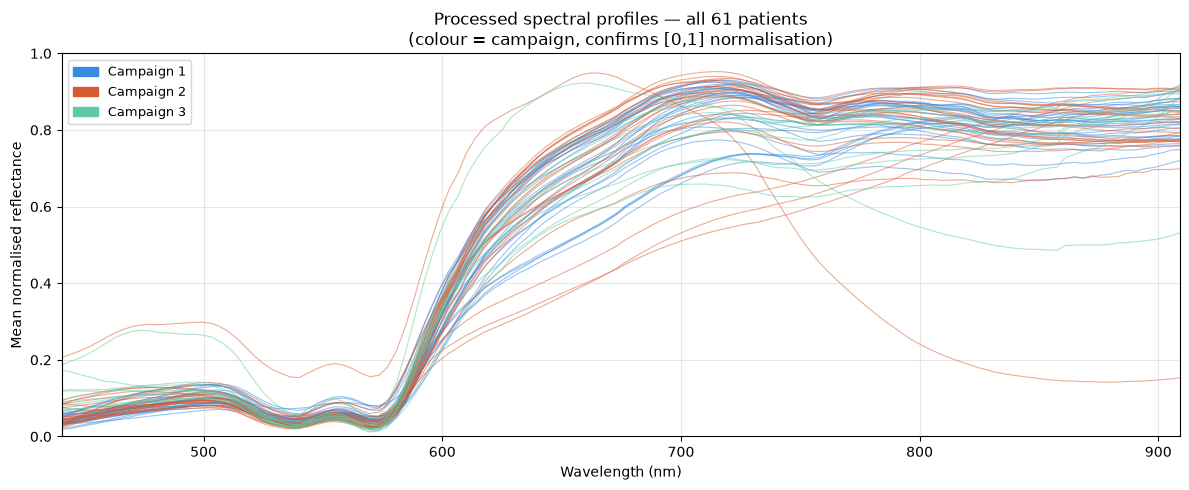

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  PLOT 1 — Processed band profiles: all patients overlaid
# ══════════════════════════════════════════════════════════════════════════════
def plot_processed_band_profiles(patients: list[dict]):
    """
    Mean processed spectrum per patient after full preprocessing pipeline.
    Colour-coded by campaign.
    Companion to plot_raw_band_profiles — confirms:
      - All patients normalised to [0, 1]
      - 128-band uniform range
      - No outlier patients surviving calibration
      - Campaign-level spectral differences visible
    """
    campaign_colors = {1: '#378ADD', 2: '#D85A30', 3: '#5DCAA5'}
    fig, ax = plt.subplots(figsize=(12, 5))

    for p in patients:
        cube  = p['processed']
        mean  = cube.reshape(-1, cube.shape[2]).mean(axis=0)
        color = campaign_colors[p['campaign']]
        ax.plot(WAVELENGTHS, mean, color=color, alpha=0.5, linewidth=0.8)

    # Legend
    handles = [
        mpatches.Patch(color=campaign_colors[c],
                       label=f"Campaign {c}")
        for c in [1, 2, 3]
    ]
    ax.legend(handles=handles, fontsize=9)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Mean normalised reflectance")
    ax.set_title("Processed spectral profiles — all 61 patients\n"
                 "(colour = campaign, confirms [0,1] normalisation)")
    ax.set_xlim(WAVELENGTHS[0], WAVELENGTHS[-1])
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / "processed_band_profiles.png",
                dpi=150, bbox_inches='tight')
    plt.show()

plot_processed_band_profiles(all_patients)

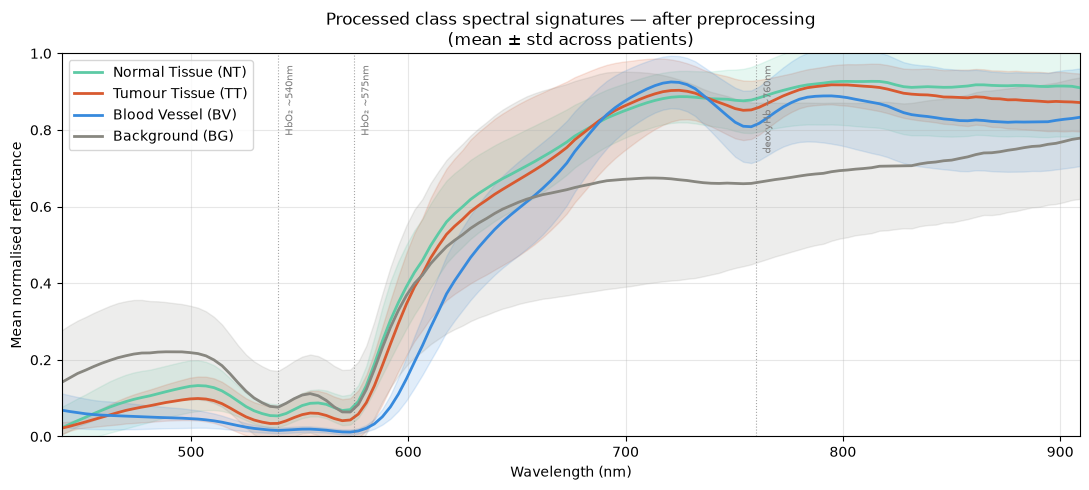

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  PLOT 2 — Processed class spectral signatures: mean ± std
# ══════════════════════════════════════════════════════════════════════════════
def plot_processed_class_spectra(patients: list[dict]):
    """
    Mean processed spectrum per tissue class across all patients.
    Companion to plot_raw_class_spectra — confirms:
      - Class ordering preserved after normalisation
      - Inter-patient std (ribbon width) reduced vs raw
      - Haemoglobin absorption features retained
      - NT sits above TT which sits above BV in NIR region
    """
    combined = {c: [] for c in [1, 2, 3, 4]}

    for p in patients:
        cube        = p['processed']
        flat_px     = cube.reshape(-1, cube.shape[2])
        flat_labels = p['labels'].reshape(-1)

        for c in [1, 2, 3, 4]:
            mask = flat_labels == c
            if mask.sum() > 0:
                combined[c].append(flat_px[mask].mean(axis=0))

    fig, ax = plt.subplots(figsize=(11, 5))

    for c in [1, 2, 3, 4]:
        if not combined[c]:
            continue
        stack = np.stack(combined[c])
        mean  = stack.mean(axis=0)
        std   = stack.std(axis=0)
        ax.plot(WAVELENGTHS, mean,
                color=CLASS_COLORS[c],
                label=CLASS_NAMES[c],      # ← was CLASS_NAMES[c+1]
                linewidth=2)
        ax.fill_between(WAVELENGTHS, mean - std, mean + std,
                        alpha=0.15, color=CLASS_COLORS[c])

    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Mean normalised reflectance")
    ax.set_title("Processed class spectral signatures — after preprocessing\n"
                 "(mean ± std across patients)")
    ax.set_xlim(WAVELENGTHS[0], WAVELENGTHS[-1])
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

    # Mark haemoglobin absorption peaks
    for wl, label in [(540, 'HbO₂ ~540nm'),
                      (575, 'HbO₂ ~575nm'),
                      (760, 'deoxyHb ~760nm')]:
        ax.axvline(wl, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        ax.text(wl + 3, 0.97, label, fontsize=7,
                color='gray', va='top', rotation=90)

    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / "processed_class_spectra.png",
                dpi=150, bbox_inches='tight')
    plt.show()

plot_processed_class_spectra(all_patients)

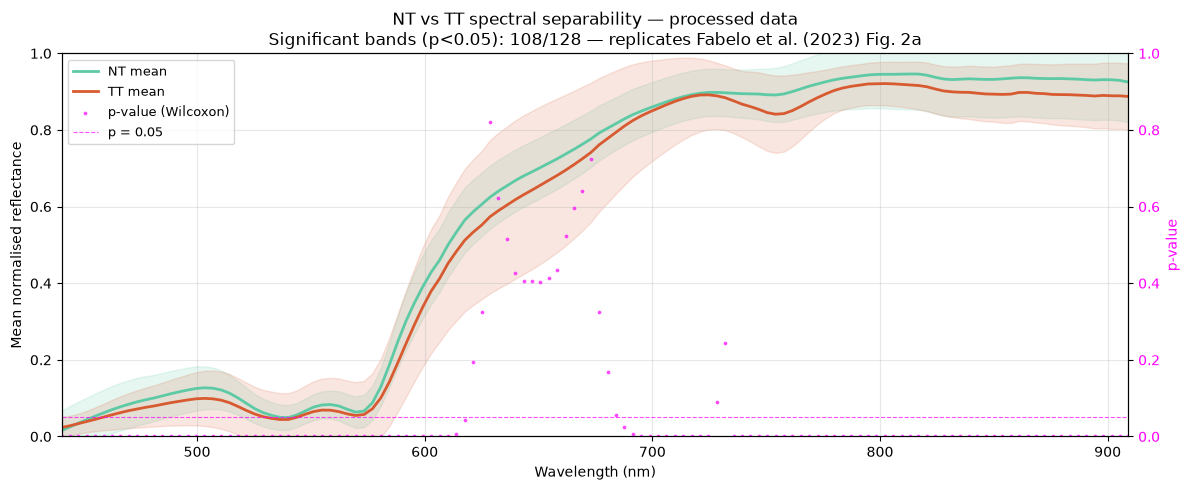


  NT pixels : 308,328
  TT pixels : 37,399
  Significant bands (p < 0.05): 108/128


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  PLOT 3 — NT vs TT separability: Wilcoxon test per band
#           Replicates Fabelo et al. (2023) Fig. 2a
# ══════════════════════════════════════════════════════════════════════════════
def plot_nt_tt_separability(patients: list[dict]):
    """
    Plot mean NT and TT spectra with per-band Wilcoxon rank-sum p-values.
    Replicates Fabelo et al. (2023) Fig. 2a — confirms the same
    statistical separability in our processed data.
    """
    nt_spectra, tt_spectra = [], []

    for p in patients:
        cube   = p['processed']
        flat   = cube.reshape(-1, cube.shape[2])
        labels = p['labels'].reshape(-1)

        nt_mask = labels == 1
        tt_mask = labels == 2

        if nt_mask.sum() > 0:
            nt_spectra.append(flat[nt_mask])
        if tt_mask.sum() > 0:
            tt_spectra.append(flat[tt_mask])

    nt_all = np.vstack(nt_spectra)
    tt_all = np.vstack(tt_spectra)

    nt_mean = nt_all.mean(axis=0)
    tt_mean = tt_all.mean(axis=0)
    nt_std  = nt_all.std(axis=0)
    tt_std  = tt_all.std(axis=0)

    # Wilcoxon rank-sum per band (subsample for speed)
    rng    = np.random.default_rng(42)
    n_sub  = min(5000, len(nt_all), len(tt_all))
    nt_sub = nt_all[rng.choice(len(nt_all), n_sub, replace=False)]
    tt_sub = tt_all[rng.choice(len(tt_all), n_sub, replace=False)]
    p_vals = np.array([
        scipy_stats.ranksums(nt_sub[:, b], tt_sub[:, b]).pvalue
        for b in range(N_DECIMATED_BANDS)
    ])

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()

    ax1.plot(WAVELENGTHS, nt_mean,
             color=CLASS_COLORS[1],        # ← was CLASS_COLORS[0]
             linewidth=2, label='NT mean')
    ax1.fill_between(WAVELENGTHS, nt_mean - nt_std, nt_mean + nt_std,
                     alpha=0.15, color=CLASS_COLORS[1])   # ← was [0]

    ax1.plot(WAVELENGTHS, tt_mean,
             color=CLASS_COLORS[2],        # ← was CLASS_COLORS[1]
             linewidth=2, label='TT mean')
    ax1.fill_between(WAVELENGTHS, tt_mean - tt_std, tt_mean + tt_std,
                     alpha=0.15, color=CLASS_COLORS[2])   # ← was [1]

    ax2.scatter(WAVELENGTHS, p_vals, color='magenta', s=3,
                alpha=0.6, label='p-value (Wilcoxon)')
    ax2.axhline(0.05, color='magenta', linestyle='--',
                linewidth=0.8, alpha=0.7, label='p = 0.05')
    ax2.set_ylabel("p-value", color='magenta')
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis='y', labelcolor='magenta')

    ax1.set_xlabel("Wavelength (nm)")
    ax1.set_ylabel("Mean normalised reflectance")
    ax1.set_xlim(WAVELENGTHS[0], WAVELENGTHS[-1])
    ax1.set_ylim(0, 1)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
    ax1.grid(alpha=0.3)

    n_sig = (p_vals < 0.05).sum()
    ax1.set_title(
        f"NT vs TT spectral separability — processed data\n"
        f"Significant bands (p<0.05): {n_sig}/{N_DECIMATED_BANDS} "
        f"— replicates Fabelo et al. (2023) Fig. 2a"
    )

    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / "processed_nt_tt_separability.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n  NT pixels : {len(nt_all):,}")
    print(f"  TT pixels : {len(tt_all):,}")
    print(f"  Significant bands (p < 0.05): {n_sig}/{N_DECIMATED_BANDS}")

plot_nt_tt_separability(all_patients)

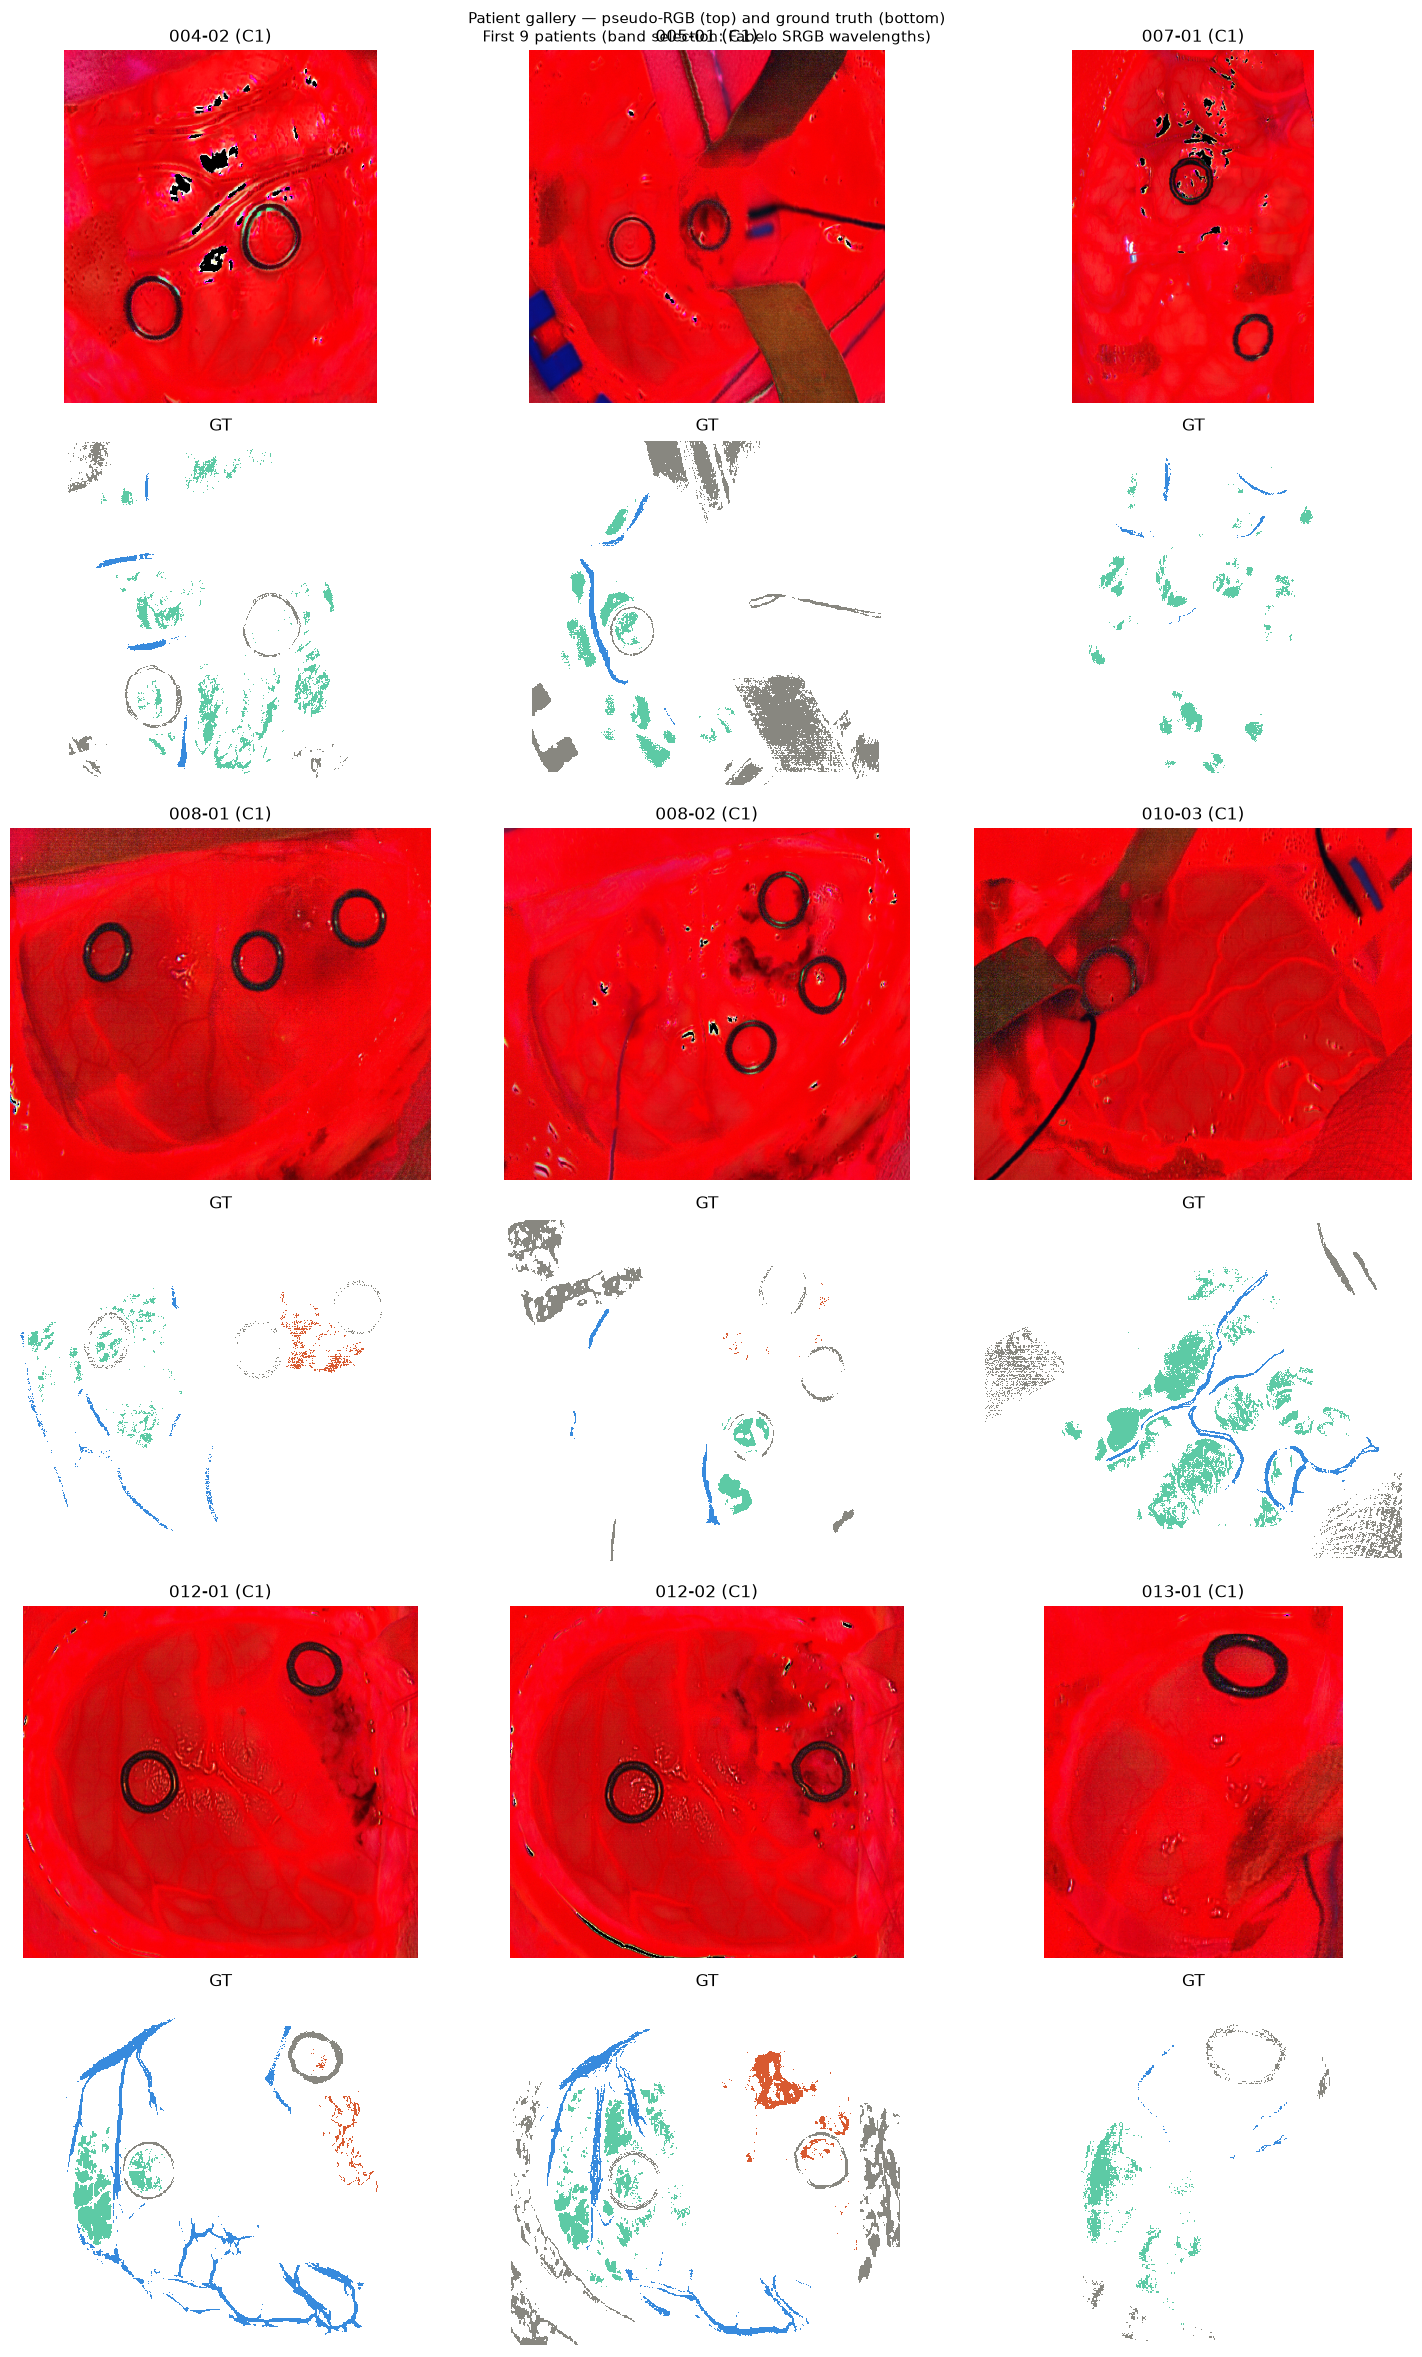

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
#  PLOT 4 — Spatial RGB views: grid of patients
# ══════════════════════════════════════════════════════════════════════════════
def plot_patient_gallery(patients: list[dict],
                         n: int = 9,
                         cols: int = 3):
    """
    Show pseudo-RGB + GT overlay for a grid of patients.
    Confirms spatial structure is preserved after preprocessing —
    tissue regions are spatially coherent, not noisy.
    """
    rows    = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols,
                              figsize=(5 * cols, 4 * rows * 2))
    fig.suptitle(
        f"Patient gallery — pseudo-RGB (top) and ground truth (bottom)\n"
        f"First {n} patients (band selection: Fabelo SRGB wavelengths)",
        fontsize=11
    )

    for i, p in enumerate(patients[:n]):
        row_rgb = (i // cols) * 2
        row_gt  = row_rgb + 1
        col     = i % cols

        show_hypercube(
            p['processed'],
            title=f"{p['id']} (C{p['campaign']})",
            ax=axes[row_rgb, col],
            show_legend=False,
        )
        show_ground_truth(
            p['labels'],
            title="GT",
            ax=axes[row_gt, col],
            show_legend=False,
        )

    # Hide unused axes
    for i in range(n, rows * cols):
        row_rgb = (i // cols) * 2
        row_gt  = row_rgb + 1
        col     = i % cols
        axes[row_rgb, col].axis('off')
        axes[row_gt,  col].axis('off')

    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / "processed_patient_gallery.png",
                dpi=120, bbox_inches='tight')
    plt.show()

plot_patient_gallery(all_patients, n=9)

/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


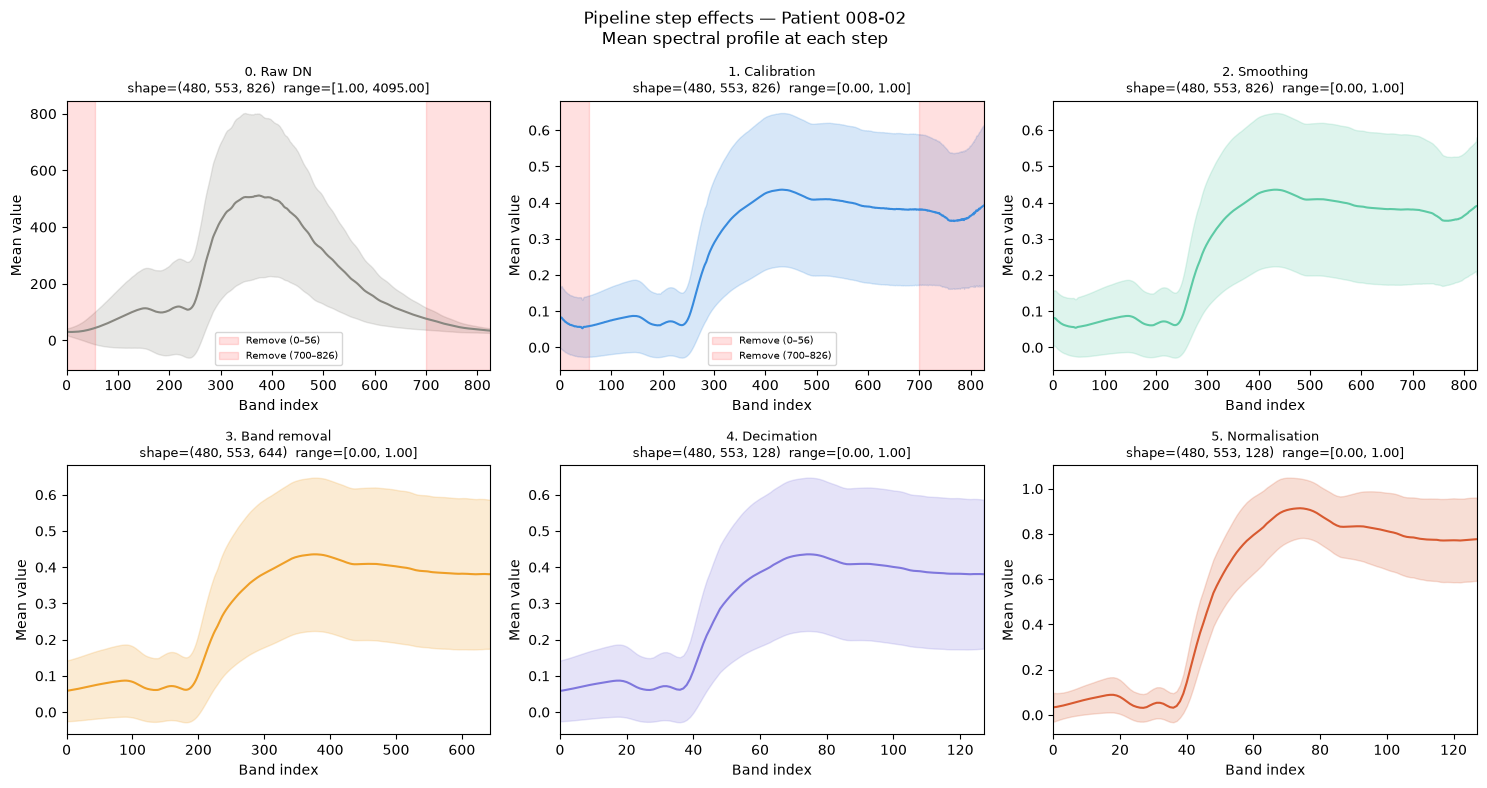

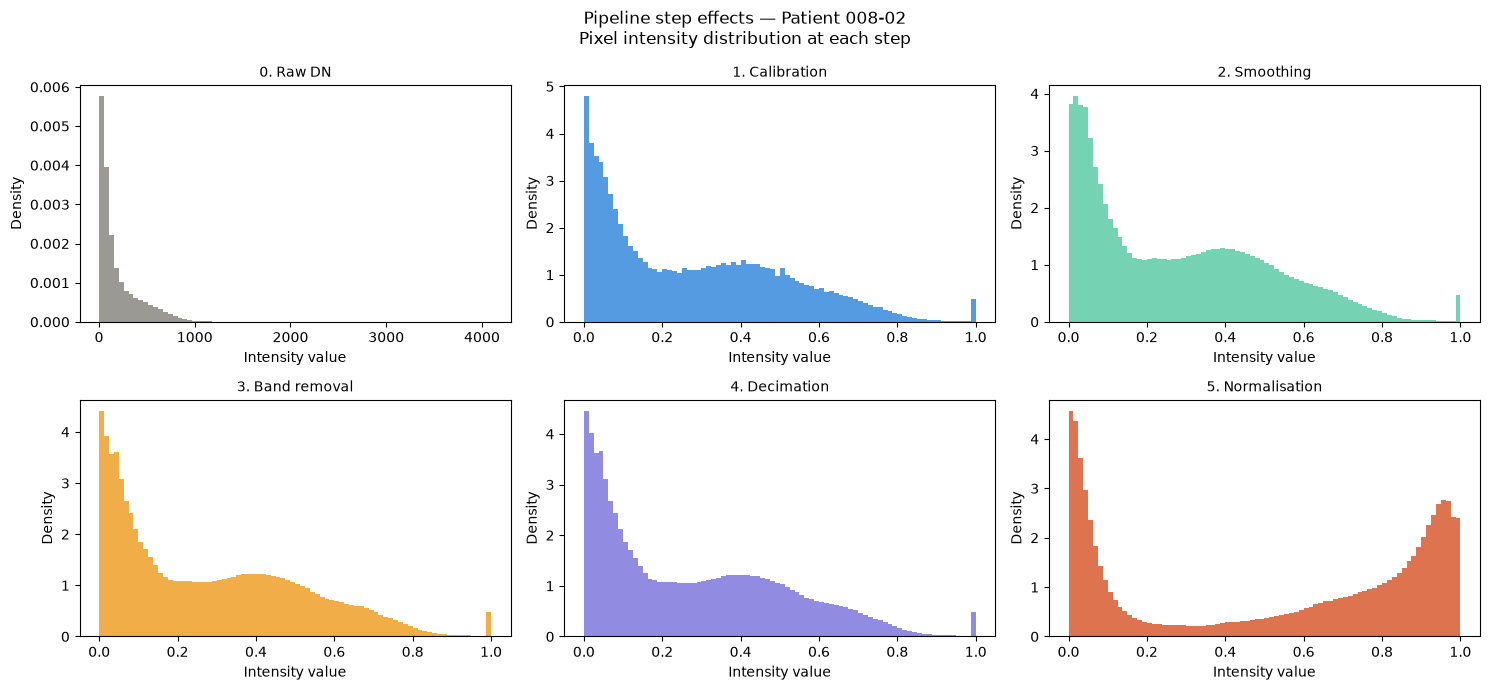


────────────────────────────────────────────────────────────────────
  Step                                Shape      Min      Max     Mean
────────────────────────────────────────────────────────────────────
  Raw DN                    (480, 553, 826)    1.000  4095.000  201.209
  Calibration               (480, 553, 826)    0.000    1.000    0.280
  Smoothing                 (480, 553, 826)    0.000    1.000    0.280
  Band removal              (480, 553, 644)    0.000    1.000    0.282
  Decimation                (480, 553, 128)    0.000    1.000    0.281
  Normalisation             (480, 553, 128)    0.000    1.000    0.541
────────────────────────────────────────────────────────────────────


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
#  PLOT 5 — Pipeline step effects on a single patient
# ══════════════════════════════════════════════════════════════════════════════
from brainvision.data import load_patient
from scipy.ndimage import uniform_filter1d

def plot_pipeline_steps(zip_path: str):
    """
    Visualise the spectral effect of each preprocessing step
    on a single patient. Shows mean spectral profile and
    pixel intensity histogram at each stage.

    Confirms:
      - Calibration brings raw DN to [0,1] reflectance
      - Smoothing reduces high-frequency noise without shifting mean
      - Band removal eliminates noisy extremes
      - Decimation preserves spectral shape at 128 bands
      - Normalisation maps per-pixel range to exactly [0,1]
    """
    patient = load_patient(zip_path)
    pid     = patient['id']
    raw     = patient['raw']
    dark    = patient['dark']
    white   = patient['white']

    # ── Apply steps ───────────────────────────────────────────────────────────
    def calibrate(r, d, w, eps=1e-6):
        dm = d.mean(axis=0, keepdims=True)
        wm = w.mean(axis=0, keepdims=True)
        return np.clip((r - dm) / (wm - dm + eps), 0, 1).astype(np.float32)

    def smooth(c):
        return uniform_filter1d(c, size=SMOOTH_WINDOW, axis=2).astype(np.float32)

    def remove_bands(c):
        return c[:, :, BAND_START_IDX:BAND_END_IDX].astype(np.float32)

    def decimate(c):
        idx = np.linspace(0, c.shape[2]-1, N_DECIMATED_BANDS, dtype=int)
        return c[:, :, idx].astype(np.float32)

    def normalise(c):
        H, W, B = c.shape
        px = c.reshape(-1, B)
        mn = px.min(axis=1, keepdims=True)
        mx = px.max(axis=1, keepdims=True)
        return ((px - mn) / (mx - mn + 1e-6)).reshape(H, W, B).astype(np.float32)

    s0 = raw
    s1 = calibrate(raw, dark, white)
    s2 = smooth(s1)
    s3 = remove_bands(s2)
    s4 = decimate(s3)
    s5 = normalise(s4)

    steps  = [s0, s1, s2, s3, s4, s5]
    names  = ["Raw DN", "Calibration", "Smoothing",
               "Band removal", "Decimation", "Normalisation"]
    colors = ['#888780', '#378ADD', '#5DCAA5',
               '#EF9F27', '#7F77DD', '#D85A30']

    # ── Figure 1: Mean spectral profile per step ──────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Pipeline step effects — Patient {pid}\n"
                 f"Mean spectral profile at each step", fontsize=12)
    axes = axes.flatten()

    for i, (s, name, color) in enumerate(zip(steps, names, colors)):
        ax   = axes[i]
        flat = s.reshape(-1, s.shape[2])
        mean = flat.mean(axis=0)
        std  = flat.std(axis=0)
        x    = np.arange(len(mean))

        ax.plot(mean, color=color, linewidth=1.5)
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)

        if i in [0, 1]:   # mark removed bands on raw and calibrated
            ax.axvspan(0, BAND_START_IDX,
                       alpha=0.12, color='red', label=f'Remove (0–{BAND_START_IDX})')
            ax.axvspan(BAND_END_IDX, s.shape[2],
                       alpha=0.12, color='red',
                       label=f'Remove ({BAND_END_IDX}–{s.shape[2]})')
            ax.legend(fontsize=7)

        ax.set_title(f"{i}. {name}\nshape={s.shape}  "
                     f"range=[{s.min():.2f}, {s.max():.2f}]",
                     fontsize=9)
        ax.set_xlabel("Band index")
        ax.set_ylabel("Mean value")
        ax.set_xlim(0, len(mean) - 1)

    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / f"pipeline_spectra_{pid}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 2: Pixel intensity histogram per step ──────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    fig.suptitle(f"Pipeline step effects — Patient {pid}\n"
                 f"Pixel intensity distribution at each step", fontsize=12)
    axes = axes.flatten()

    for i, (s, name, color) in enumerate(zip(steps, names, colors)):
        ax     = axes[i]
        sample = s.reshape(-1)[::10]
        ax.hist(sample, bins=80, color=color, alpha=0.85, density=True)
        ax.set_title(f"{i}. {name}", fontsize=10)
        ax.set_xlabel("Intensity value")
        ax.set_ylabel("Density")

    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / f"pipeline_histograms_{pid}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary stats table ───────────────────────────────────────────────────
    print(f"\n{'─'*68}")
    print(f"  {'Step':<22} {'Shape':>18}  {'Min':>7}  {'Max':>7}  {'Mean':>7}")
    print(f"{'─'*68}")
    for s, name in zip(steps, names):
        print(f"  {name:<22} {str(s.shape):>18}  "
              f"{s.min():>7.3f}  {s.max():>7.3f}  {s.mean():>7.3f}")
    print(f"{'─'*68}")

# Run on a TT-containing patient for meaningful class spectra
EXAMPLE_PATIENT = CAMPAIGN_DIRS[1] + "/008-02.zip"
plot_pipeline_steps(EXAMPLE_PATIENT)

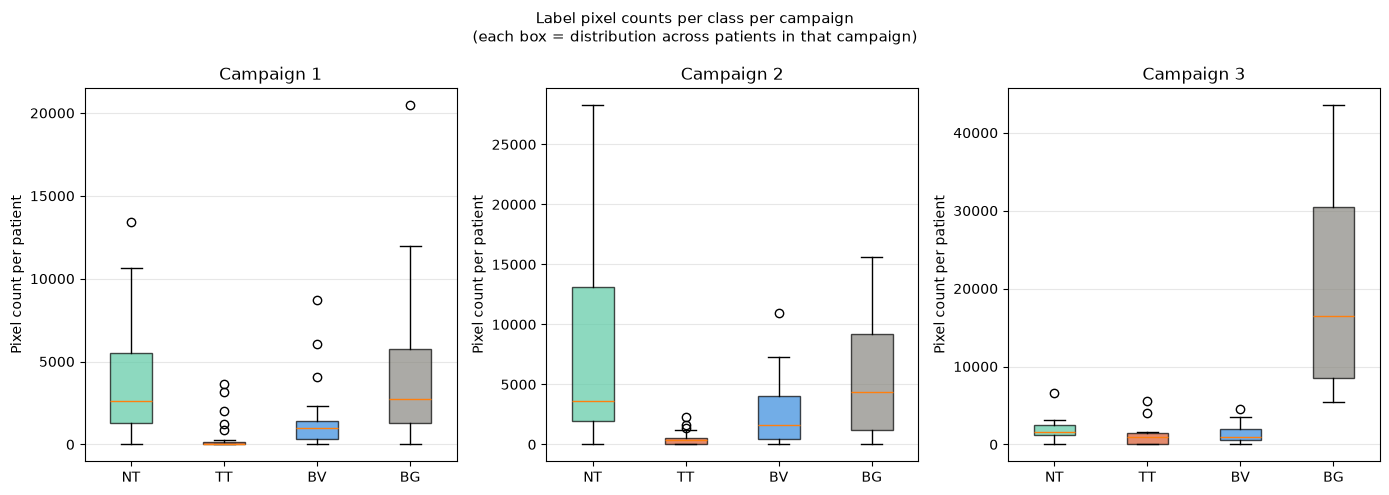

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  PLOT 6 — Label map statistics: pixel counts per class per patient
# ══════════════════════════════════════════════════════════════════════════════
def plot_label_statistics(patients: list[dict]):
    """
    Box plots showing per-patient pixel counts per class, split by campaign.
    Confirms label distribution is consistent with raw EDA findings:
      - TT is the rarest class
      - BG dominates Campaign 3
      - NT:TT ratio is most severe in Campaign 2
    """
    from collections import defaultdict

    counts = {c: defaultdict(list) for c in [1, 2, 3]}

    for p in patients:
        labels  = p['labels'].reshape(-1)
        camp    = p['campaign']
        for cls in [1, 2, 3, 4]:
            counts[camp][cls].append((labels == cls).sum())

    cls_names  = ['NT', 'TT', 'BV', 'BG']
    cls_colors = CLASS_COLORS

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
    fig.suptitle("Label pixel counts per class per campaign\n"
                 "(each box = distribution across patients in that campaign)",
                 fontsize=11)

    for camp_idx, campaign_id in enumerate([1, 2, 3]):
        ax   = axes[camp_idx]
        data = [counts[campaign_id][cls] for cls in [1, 2, 3, 4]]

        bp = ax.boxplot(data, patch_artist=True, notch=False)
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(cls_colors[i+1])
            patch.set_alpha(0.7)

        ax.set_xticklabels(cls_names)
        ax.set_title(f"Campaign {campaign_id}")
        ax.set_ylabel("Pixel count per patient")
        ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / "processed_label_statistics.png",
                dpi=150, bbox_inches='tight')
    plt.show()


plot_label_statistics(all_patients)

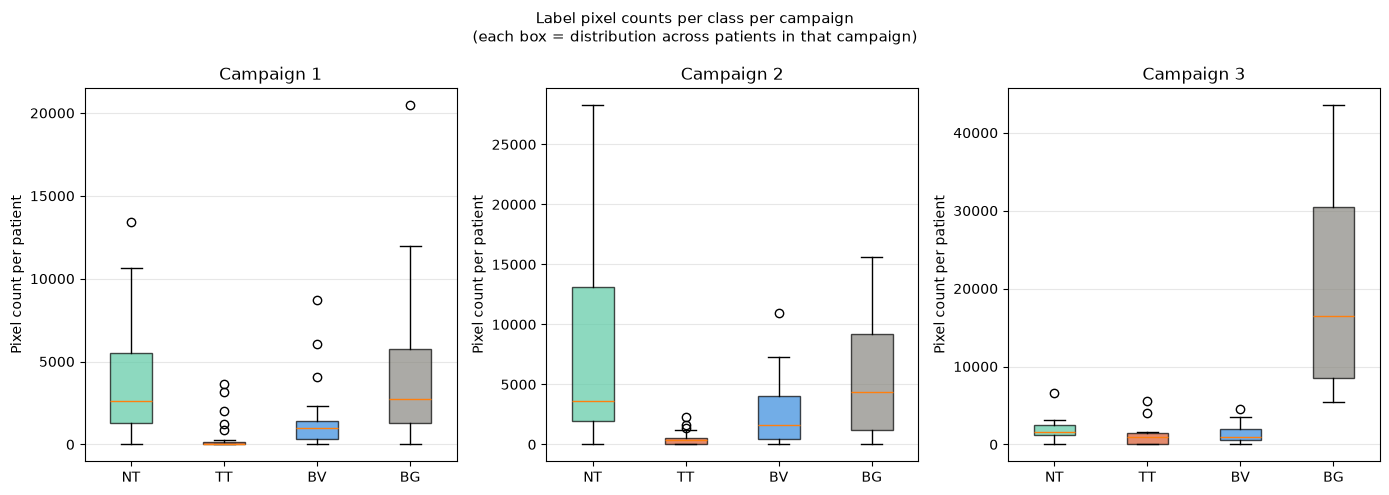

 Campaign Class  N patients  Mean  Median   Std  Min   Max  Total
        1    NT          27  3767    2643  3361    0 13450 101706
        1    TT          27   423       0   978    0  3655  11422
        1    BV          27  1448     965  1961    0  8697  39084
        1    BG          27  4375    2767  4661    0 20483 118132
        2    NT          24  7755    3602  8139    0 28285 186122
        2    TT          24   477     345   596    0  2295  11438
        2    BV          24  2424    1627  2705    0 10956  58183
        2    BG          24  5282    4394  4473    0 15609 126773
        3    NT          10  2050    1560  1860    0  6589  20500
        3    TT          10  1454     908  1885    0  5549  14539
        3    BV          10  1514    1008  1474    0  4565  15140
        3    BG          10 20064   16475 13618 5502 43565 200635

NT:TT ratio per campaign:
 Campaign  NT:TT ratio
        1         8.90
        2        16.27
        3         1.41


In [12]:
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ══════════════════════════════════════════════════════════════════════════════
#  Shared logic — compute per-patient, per-class, per-campaign pixel counts
# ══════════════════════════════════════════════════════════════════════════════
def compute_label_statistics(patients: list[dict]) -> dict[int, dict[int, list[int]]]:
    """
    Computes per-patient pixel counts per class per campaign.

    Returns:
        counts[campaign_id][class_id] -> list of pixel counts, one per patient
        in that campaign (class_id in {1: NT, 2: TT, 3: BV, 4: BG})
    """
    counts = {c: defaultdict(list) for c in [1, 2, 3]}

    for p in patients:
        labels = p['labels'].reshape(-1)
        camp   = p['campaign']
        for cls in [1, 2, 3, 4]:
            counts[camp][cls].append(int((labels == cls).sum()))

    return counts


# ══════════════════════════════════════════════════════════════════════════════
#  PLOT 6 — Label map statistics: box plots
# ══════════════════════════════════════════════════════════════════════════════
def plot_label_statistics(counts: dict[int, dict[int, list[int]]]):
    """
    Box plots showing per-patient pixel counts per class, split by campaign.
    Confirms label distribution is consistent with raw EDA findings:
      - TT is the rarest class
      - BG dominates Campaign 3
      - NT:TT ratio is most severe in Campaign 2
    """
    cls_names  = ['NT', 'TT', 'BV', 'BG']
    cls_colors = CLASS_COLORS

    fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
    fig.suptitle("Label pixel counts per class per campaign\n"
                 "(each box = distribution across patients in that campaign)",
                 fontsize=11)

    for camp_idx, campaign_id in enumerate([1, 2, 3]):
        ax   = axes[camp_idx]
        data = [counts[campaign_id][cls] for cls in [1, 2, 3, 4]]

        bp = ax.boxplot(data, patch_artist=True, notch=False)
        for i, patch in enumerate(bp['boxes']):
            patch.set_facecolor(cls_colors[i + 1])
            patch.set_alpha(0.7)

        ax.set_xticklabels(cls_names)
        ax.set_title(f"Campaign {campaign_id}")
        ax.set_ylabel("Pixel count per patient")
        ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(Path(RESULTS_DIR) / "processed_label_statistics.png",
                dpi=150, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════════════════════
#  TABLE — Label map statistics as numbers
# ══════════════════════════════════════════════════════════════════════════════
def print_label_statistics_table(counts: dict[int, dict[int, list[int]]]):
    """
    Turns the same per-patient counts into a summary table (mean, median, std,
    min, max, total) plus NT:TT ratio per campaign. Prints and saves to CSV.
    """
    cls_names = {1: 'NT', 2: 'TT', 3: 'BV', 4: 'BG'}
    rows = []

    for campaign_id in [1, 2, 3]:
        for cls in [1, 2, 3, 4]:
            vals = pd.Series(counts[campaign_id][cls], dtype='float64')
            rows.append({
                'Campaign': campaign_id,
                'Class': cls_names[cls],
                'N patients': vals.count(),
                'Mean': vals.mean(),
                'Median': vals.median(),
                'Std': vals.std(),
                'Min': vals.min(),
                'Max': vals.max(),
                'Total': vals.sum(),
            })

    stats_df = pd.DataFrame(rows)

    ratio_rows = []
    for campaign_id in [1, 2, 3]:
        nt_total = stats_df[(stats_df.Campaign == campaign_id) & (stats_df.Class == 'NT')]['Total'].values[0]
        tt_total = stats_df[(stats_df.Campaign == campaign_id) & (stats_df.Class == 'TT')]['Total'].values[0]
        ratio_rows.append({'Campaign': campaign_id, 'NT:TT ratio': nt_total / tt_total})
    ratio_df = pd.DataFrame(ratio_rows)

    display_df = stats_df.copy()
    for col in ['Mean', 'Median', 'Std', 'Min', 'Max', 'Total']:
        display_df[col] = display_df[col].round(0).astype('Int64')

    print(display_df.to_string(index=False))
    print("\nNT:TT ratio per campaign:")
    print(ratio_df.round(2).to_string(index=False))

    display_df.to_csv(Path(RESULTS_DIR) / "processed_label_statistics.csv", index=False)
    ratio_df.to_csv(Path(RESULTS_DIR) / "processed_label_nt_tt_ratio.csv", index=False)

    return display_df, ratio_df


# ══════════════════════════════════════════════════════════════════════════════
#  Run once, feed both consumers
# ══════════════════════════════════════════════════════════════════════════════
label_counts = compute_label_statistics(all_patients)
plot_label_statistics(label_counts)
stats_df, ratio_df = print_label_statistics_table(label_counts)

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  SUMMARY — key numbers for LOGS.md
# ══════════════════════════════════════════════════════════════════════════════
def print_processed_summary(patients: list[dict]):
    """Print key statistics for the processed dataset."""
    total_pixels = 0
    class_pixels = {c: 0 for c in [1, 2, 3, 4]}

    for p in patients:
        labels = p['labels'].reshape(-1)
        for c in [1, 2, 3, 4]:
            n = (labels == c).sum()
            class_pixels[c] += n
            total_pixels    += n

    print(f"\n{'═'*55}")
    print(f"  PROCESSED DATASET SUMMARY")
    print(f"{'═'*55}")
    print(f"  Patients            : {len(patients)}")
    print(f"  Total labelled px   : {total_pixels:,}")
    print(f"\n  Class pixel counts:")
    cls_names = {1: 'NT', 2: 'TT', 3: 'BV', 4: 'BG'}
    for c in [1, 2, 3, 4]:
        pct = class_pixels[c] / total_pixels * 100
        print(f"    {cls_names[c]} : {class_pixels[c]:>8,}  ({pct:.1f}%)")

    nt_tt = class_pixels[1] / class_pixels[2] if class_pixels[2] > 0 else float('inf')
    print(f"\n  NT:TT ratio         : {nt_tt:.1f}:1")
    print(f"  TT % of labelled    : {class_pixels[2]/total_pixels*100:.2f}%")

print_processed_summary(all_patients)


═══════════════════════════════════════════════════════
  PROCESSED DATASET SUMMARY
═══════════════════════════════════════════════════════
  Patients            : 61
  Total labelled px   : 903,674

  Class pixel counts:
    NT :  308,328  (34.1%)
    TT :   37,399  (4.1%)
    BV :  112,407  (12.4%)
    BG :  445,540  (49.3%)

  NT:TT ratio         : 8.2:1
  TT % of labelled    : 4.14%
